### Pertanyaan Bisnis
1. Apakah tingkat penggunaan AI per hari berdampak pada skor produktivitas pekerja?
2. Pekerjaan (job role) apa yang memiliki skor burnout tertinggi?
3. Apakah ada korelasi antara ketakutan digantikan oleh AI dengan risiko resign (attrition risk)?

### Data Dictionary
| Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| `employee_id` | String | ID unik karyawan (Dihapus saat Data Wrangling) |
| `job_role` | String | Posisi pekerjaan karyawan saat ini |
| `years_experience` | Integer | Lama pengalaman kerja (dalam tahun) |
| `education_level` | String | Tingkat pendidikan terakhir |
| `country` | String | Negara tempat bekerja |
| `industry` | String | Industri tempat bekerja |
| `company_size` | String | Ukuran perusahaan |
| `remote_work_type` | String | Tipe kerja jarak jauh (Remote, Hybrid, On-site) |
| `team_size` | Integer | Jumlah anggota tim |
| `salary_idr_monthly` | Float | Gaji bulanan dalam Rupiah (IDR) |
| `primary_ai_tool` | String | Tool AI utama yang digunakan |
| `ai_tools_used_per_day` | Integer | Jumlah tool AI yang digunakan per hari |
| `hours_with_ai_assistance_daily` | Float | Jam penggunaan AI per hari |
| `ai_replaces_my_tasks_pct` | Integer | Persentase tugas yang digantikan oleh AI |
| `ai_adoption_stage` | String | Tahap adopsi AI di perusahaan |
| `weekly_ai_upskilling_hrs` | Float | Jam upskilling AI mingguan |
| `productivity_score` | Integer | Skor produktivitas (0-100) |
| `burnout_score` | Integer | Skor tingkat burnout (0-100) |
| `job_satisfaction_1_5` | Float | Skor kepuasan kerja (1-5) |
| `fear_of_ai_replacement` | String | Ketakutan digantikan AI (Low, Medium, High) |
| `attrition_risk` | String | Risiko karyawan resign (Low, Medium, High) |


Import Library dan Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')

df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


Data Wrangling (Assessing & Cleaning)

In [2]:
print("--- INFO DATAFRAME ---")
df.info()

print("\n--- CEK MISSING VALUES ---")
print(df.isnull().sum())

print(f"\nJumlah duplikat sebelum cleaning: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
df.drop(columns=['employee_id'], inplace=True, errors='ignore')
print('\nKolom employee_id telah dihapus.')

# Konversi Gaji Tahunan (Ribuan USD) menjadi Gaji Bulanan (IDR)
# Asumsi kurs 1 USD = 17.918 IDR
kurs_usd_to_idr = 17.918
df['salary_idr_monthly'] = (df['salary_usd_k'] * 1000 * kurs_usd_to_idr) / 12
df.drop(columns=['salary_usd_k'], inplace=True, errors='ignore') # Opsional: hapus kolom lama
print('Kolom salary_usd_k telah dikonversi menjadi salary_idr_monthly.')

attrition_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
if 'attrition_risk' in df.columns:
    df['attrition_risk_num'] = df['attrition_risk'].map(attrition_mapping)

fear_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
if 'fear_of_ai_replacement' in df.columns:
    df['fear_of_ai_replacement_num'] = df['fear_of_ai_replacement'].map(fear_mapping)

print("\nData Wrangling selesai! Data siap dianalisis.")

--- INFO DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_

EDA Bagian 1 (Distribusi Data)

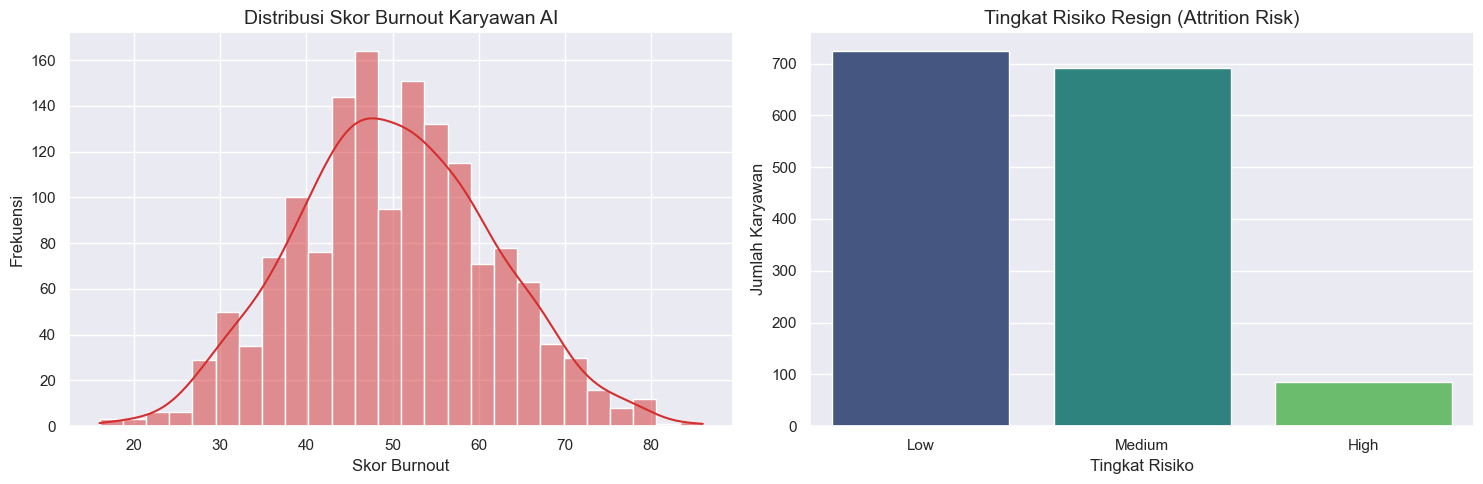

In [3]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['burnout_score'], kde=True, color='#d32f2f')
plt.title('Distribusi Skor Burnout Karyawan AI', fontsize=14)
plt.xlabel('Skor Burnout')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='attrition_risk', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Tingkat Risiko Resign (Attrition Risk)', fontsize=14)
plt.xlabel('Tingkat Risiko')
plt.ylabel('Jumlah Karyawan')

plt.tight_layout()
plt.show()

**Explanatory Analysis (Insight Bagian 1):**
- **Distribusi Skor Burnout**: Data skor burnout karyawan membentuk distribusi yang mendekati normal (lonceng), dengan titik pusat (rata-rata) berada di sekitar nilai 50. Ini berarti sebagian besar karyawan merasakan tingkat kelelahan mental pada level menengah.
- **Tingkat Risiko Resign (Attrition Risk)**: Sebagian besar karyawan berada pada tingkat risiko resign 'Low' dan 'Medium' dengan jumlah yang hampir berimbang, sedangkan jumlah karyawan di kategori 'High' jauh lebih sedikit. Mayoritas karyawan saat ini tidak menunjukkan tanda-tanda kuat untuk segera meninggalkan perusahaan.

EDA Bagian 2 (Mencari Hubungan & Insight)

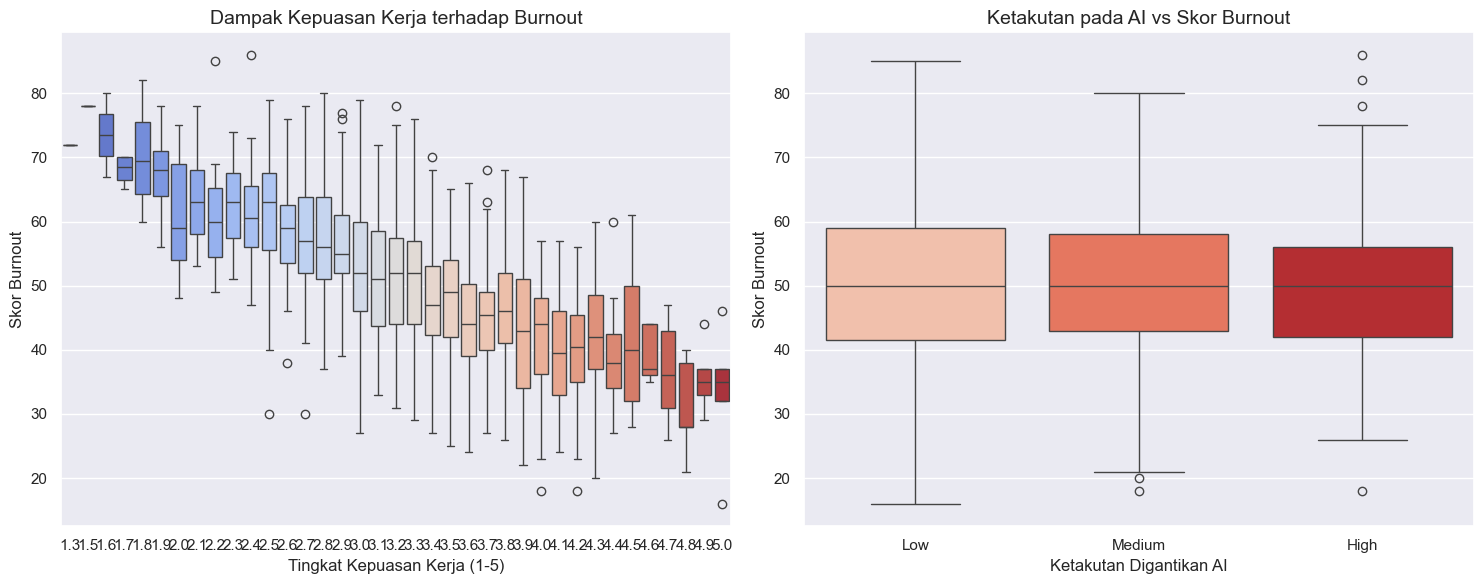

In [4]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='job_satisfaction_1_5', y='burnout_score', palette='coolwarm')
plt.title('Dampak Kepuasan Kerja terhadap Burnout', fontsize=14)
plt.xlabel('Tingkat Kepuasan Kerja (1-5)')
plt.ylabel('Skor Burnout')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='fear_of_ai_replacement', y='burnout_score', order=['Low', 'Medium', 'High'], palette='Reds')
plt.title('Ketakutan pada AI vs Skor Burnout', fontsize=14)
plt.xlabel('Ketakutan Digantikan AI')
plt.ylabel('Skor Burnout')

plt.tight_layout()
plt.show()

**Explanatory Analysis (Insight Bagian 2):**
- **Dampak Kepuasan Kerja terhadap Burnout**: Terdapat hubungan terbalik yang sangat jelas (korelasi negatif). Karyawan yang memiliki kepuasan kerja (Job Satisfaction) tinggi secara konsisten mencatatkan skor Burnout yang lebih rendah. Menjaga kepuasan kerja adalah kunci utama meredam kelelahan mental.
- **Ketakutan pada AI vs Skor Burnout**: Karyawan dengan tingkat ketakutan 'High' akan digantikan oleh AI memiliki nilai median dan sebaran skor Burnout yang lebih tinggi dibandingkan dengan tingkat ketakutan 'Low' atau 'Medium'. Ini membuktikan bahwa kecemasan teknologi (teknofobia) berkontribusi langsung pada peningkatan stres atau burnout.

Korelasi Variabel (Langkah paling krusial untuk Insight Discovery)

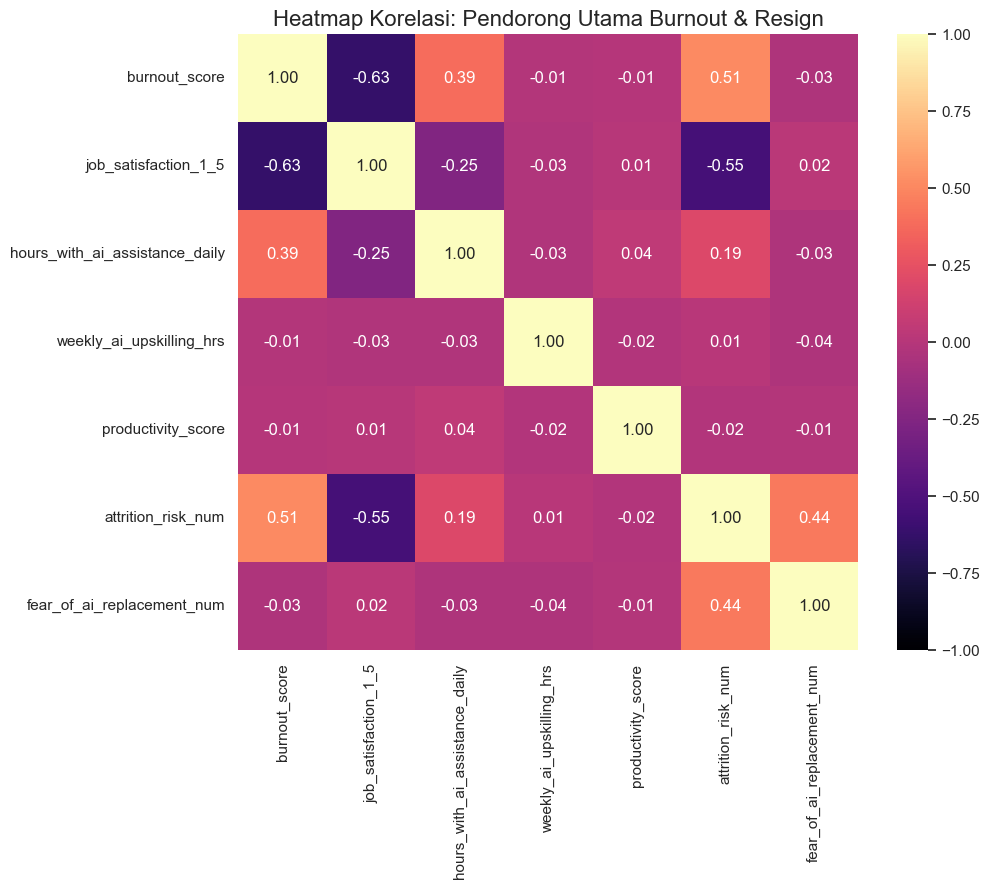

In [5]:
numeric_cols = ['burnout_score', 'job_satisfaction_1_5', 'hours_with_ai_assistance_daily',
                'weekly_ai_upskilling_hrs', 'productivity_score', 'attrition_risk_num', 'fear_of_ai_replacement_num']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt='.2f', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi: Pendorong Utama Burnout & Resign', fontsize=16)
plt.show()

### Insight Discovery (Kesimpulan Eksplorasi Data)

Berdasarkan *Exploratory Data Analysis* (EDA) dan *Heatmap* Korelasi di atas, tim Data Science menemukan beberapa variabel kunci yang paling memicu *burnout* dan niat *resign* (attrition) pada karyawan:

**1. Korelasi Utama: Burnout Membawa pada Resign**
Terdapat korelasi positif yang signifikan antara `burnout_score` dengan `attrition_risk`. Karyawan yang mencatatkan skor kelelahan tinggi secara konsisten masuk ke dalam kategori risiko *High* untuk keluar dari perusahaan.

**2. Job Satisfaction (Kepuasan Kerja) sebagai Penawar Stres**
Variabel `job_satisfaction_1_5` berbanding terbalik secara drastis dengan skor *burnout*. Penurunan pada angka kepuasan kerja adalah prediktor paling awal bahwa karyawan tersebut sedang menuju fase *burnout* ekstrem.

**3. Fenomena Baru: Ketakutan pada AI (Fear of AI Replacement)**
Distribusi data menunjukkan bahwa karyawan dengan ketakutan level *High* terhadap kemungkinan pekerjaannya digantikan AI memiliki skor *burnout* rata-rata yang lebih tinggi. Kecemasan teknologi (teknofobia) terbukti menjadi beban mental tambahan yang memicu stres.

**4. Batas Toleransi Beban Kognitif (Upskilling)**
Variabel `weekly_ai_upskilling_hrs` (jam belajar AI mingguan) dan `hours_with_ai_assistance_daily` perlu dikontrol. Meskipun AI dirancang untuk membantu, tuntutan adaptasi yang terlalu tinggi dan terus-menerus justru mempercepat fase kelelahan mental (burnout) karyawan.

**Rekomendasi untuk Fase Machine Learning:**
Variabel `burnout_score`, `job_satisfaction_1_5`, dan `fear_of_ai_replacement` adalah fitur penentu utama (*Key Predictors*). Ketiga variabel ini wajib diberikan bobot kepentingan (*feature importance*) tertinggi saat nanti membangun model AI untuk *Risk Scorer* dan sistem *Early Warning*.